## **0. Library import**

In [31]:
import os
import sys

# Add the root path into the python path
root_path = os.path.abspath(os.path.join(".."))
if not root_path in sys.path:
    sys.path.insert(0, root_path)

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from src.features import DiabetesFeatureEngineering
from src.config import BRFSS_FILTERING_FILE_PATH

## **1. Load dataset**

In [3]:
df = pd.read_csv(BRFSS_FILTERING_FILE_PATH)
df.shape

(787646, 21)

## **2. Feature engineering**

In [6]:
diabetes_feature_engineering = DiabetesFeatureEngineering("../logs/feature_engineering.log")

2025-07-20 09:27:01,394 - [src.features] - INFO - DiabetesFeatureEngineering initialized successfully


### **2.1 Remove null values**

In [7]:
clean_df = diabetes_feature_engineering.remove_null_values(df)

2025-07-20 09:28:14,772 - [src.features] - INFO - Starting null values removal process...
2025-07-20 09:28:14,791 - [src.features] - INFO - No null values found in the dataset
2025-07-20 09:28:15,347 - [src.features] - INFO - Null values removal completed. Removed 0 rows (0.00%)
2025-07-20 09:28:15,348 - [src.features] - INFO - Dataset shape: 787646 -> 787646 rows


### **2.2 Remove duplicate values**

In [8]:
no_dup_df = diabetes_feature_engineering.remove_duplicates(clean_df)

2025-07-20 09:28:40,449 - [src.features] - INFO - Starting duplicate removal process...
2025-07-20 09:28:40,715 - [src.features] - INFO - Found 85086 duplicate rows
2025-07-20 09:28:41,467 - [src.features] - INFO - Duplicate removal completed. Removed 85086 rows (10.80%)
2025-07-20 09:28:41,468 - [src.features] - INFO - Dataset shape: 787646 -> 702560 rows


### **2.3 Handle outliers**

In [9]:
outliers_df = diabetes_feature_engineering.handle_outliers(no_dup_df)

2025-07-20 09:29:08,848 - [src.features] - INFO - Starting outlier handling process...
2025-07-20 09:29:08,849 - [src.features] - INFO - Columns to process: ['BMI', 'MentHlth', 'PhysHlth']
2025-07-20 09:29:09,049 - [src.features] - INFO - Processing outliers for column: BMI
2025-07-20 09:29:09,073 - [src.features] - INFO -   - Total outliers: 18686 (Lower: 0, Upper: 18686)
2025-07-20 09:29:09,079 - [src.features] - INFO - Processing outliers for column: MentHlth
2025-07-20 09:29:09,099 - [src.features] - INFO -   - Total outliers: 90556 (Lower: 0, Upper: 90556)
2025-07-20 09:29:09,107 - [src.features] - INFO - Processing outliers for column: PhysHlth
2025-07-20 09:29:09,128 - [src.features] - INFO -   - Total outliers: 105110 (Lower: 0, Upper: 105110)
2025-07-20 09:29:09,136 - [src.features] - INFO - Outlier handling completed. Total outliers handled: 214352


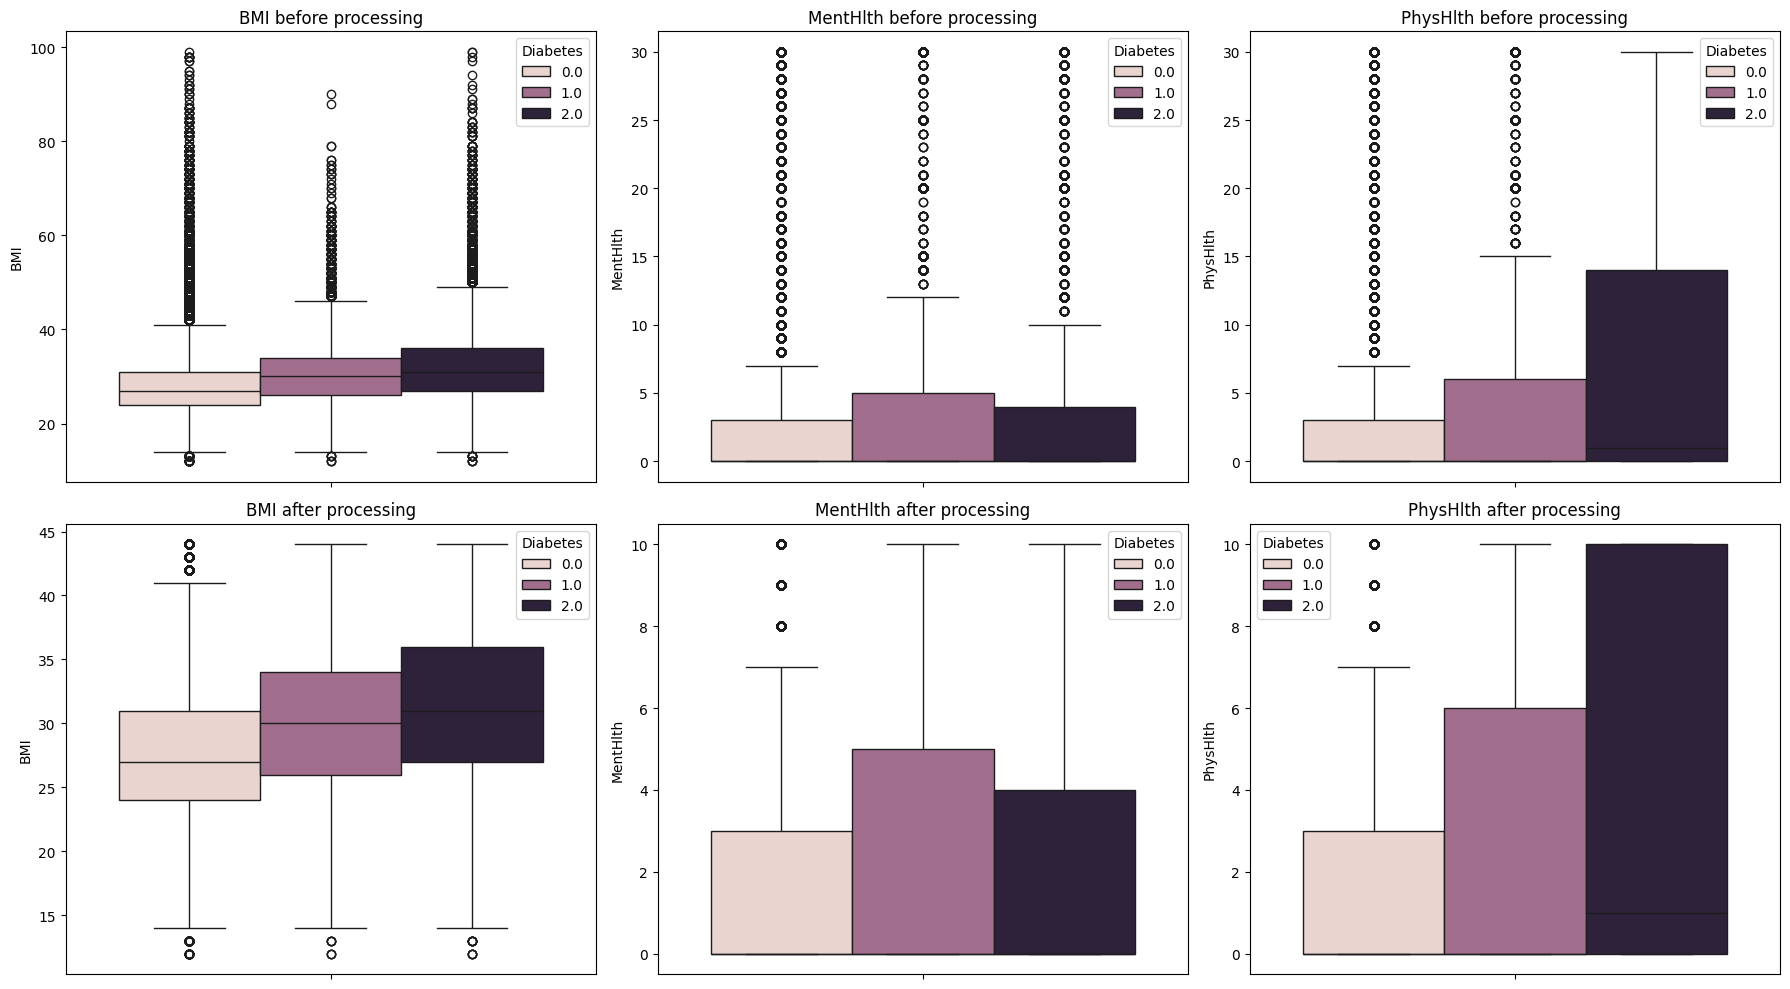

In [12]:
# Plot comparison chart before and after processing
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Before processing
sns.boxplot(data=no_dup_df, y='BMI', hue='Diabetes', ax=axes[0,0])
axes[0,0].set_title('BMI before processing')
sns.boxplot(data=no_dup_df, y='MentHlth', hue='Diabetes', ax=axes[0,1])
axes[0,1].set_title('MentHlth before processing')
sns.boxplot(data=no_dup_df, y='PhysHlth', hue='Diabetes', ax=axes[0,2])
axes[0,2].set_title('PhysHlth before processing')

# After processing
sns.boxplot(data=outliers_df, y='BMI', hue='Diabetes', ax=axes[1,0])
axes[1,0].set_title('BMI after processing')
sns.boxplot(data=outliers_df, y='MentHlth', hue='Diabetes', ax=axes[1,1])
axes[1,1].set_title('MentHlth after processing')
sns.boxplot(data=outliers_df, y='PhysHlth', hue='Diabetes', ax=axes[1,2])
axes[1,2].set_title('PhysHlth after processing')

plt.tight_layout()
plt.show()

### **2.4 Exploratory Data Analysis**

In [14]:
hlth_score_df = diabetes_feature_engineering.create_health_score(outliers_df)
hlth_score_df["HlthScore"].unique()

2025-07-20 09:34:40,304 - [src.features] - INFO - Creating health score feature...
2025-07-20 09:34:40,370 - [src.features] - INFO - Health score created successfully. Range: [0.200, 1.667]


array([0.4       , 1.13333333, 0.8       , 0.6       , 0.93333333,
       0.7       , 0.76666667, 1.33333333, 1.2       , 1.66666667,
       0.66666667, 0.53333333, 1.26666667, 0.2       , 0.46666667,
       0.43333333, 0.73333333, 0.63333333, 0.5       , 0.86666667,
       0.26666667, 0.73333333, 1.46666667, 0.83333333, 0.23333333,
       0.96666667, 0.76666667, 0.83333333, 0.9       , 1.1       ,
       1.16666667, 1.3       , 1.36666667, 1.1       , 1.4       ,
       1.        , 0.8       , 0.36666667, 1.23333333, 1.06666667,
       1.5       , 0.86666667, 0.56666667, 1.03333333, 0.3       ,
       1.2       , 1.26666667, 1.43333333, 1.46666667, 1.53333333,
       1.56666667, 1.16666667, 0.3       , 0.9       , 0.93333333,
       0.33333333, 0.66666667, 1.03333333, 0.96666667, 0.96666667,
       0.6       , 0.33333333, 1.33333333, 1.06666667, 0.63333333,
       1.        , 1.13333333, 0.53333333, 0.9       , 1.63333333,
       0.7       , 1.4       , 1.6       , 1.23333333, 1.6    

In [16]:
risk_score_df = diabetes_feature_engineering.create_risk_score(hlth_score_df)
risk_score_df["RiskScore"].unique()

2025-07-20 09:35:52,215 - [src.features] - INFO - Creating risk score feature...
2025-07-20 09:35:52,817 - [src.features] - INFO - Risk score created successfully using 4 features. Range: [0.0, 4.0]


array([2., 1., 0., 3., 4.])

In [18]:
life_style_df = diabetes_feature_engineering.create_lifestyle_score(risk_score_df)
life_style_df["LifestyleScore"].unique()

2025-07-20 09:36:54,635 - [src.features] - INFO - Creating lifestyle score feature...
2025-07-20 09:36:55,157 - [src.features] - INFO - Lifestyle score created successfully using 1 positive and 2 negative factors
2025-07-20 09:36:55,160 - [src.features] - INFO - Range: [-2.0, 1.0]


array([ 1., -1.,  0., -2.])

In [19]:
cardio_risk_df = diabetes_feature_engineering.create_cardio_risk(life_style_df)
cardio_risk_df["CardioRisk"].unique()

2025-07-20 09:37:55,735 - [src.features] - INFO - Creating cardiovascular risk feature...
2025-07-20 09:37:56,152 - [src.features] - INFO - Cardiovascular risk created successfully using: ['HighBP', 'HighChol', 'BMI_Obesity']
2025-07-20 09:37:56,156 - [src.features] - INFO - Range: [0.0, 3.0]


array([2., 1., 0., 3.])

In [20]:
healthy_lifestyle = diabetes_feature_engineering.create_healthy_lifestyle(cardio_risk_df)
healthy_lifestyle["HealthyLifestyle"].unique()

2025-07-20 09:39:11,436 - [src.features] - INFO - Creating healthy lifestyle feature...
2025-07-20 09:39:11,990 - [src.features] - INFO - Healthy lifestyle feature created using 1 positive and 2 negative factors
2025-07-20 09:39:11,993 - [src.features] - INFO - Range: [-2.0, 1.0]


array([ 1., -1.,  0., -2.])

In [22]:
bmi_category_df = diabetes_feature_engineering.create_bmi_category(healthy_lifestyle)
bmi_category_df["BMICategory"].unique()

2025-07-20 09:39:58,241 - [src.features] - INFO - Creating BMI category feature...
2025-07-20 09:39:59,027 - [src.features] - INFO - BMI category distribution:
2025-07-20 09:39:59,028 - [src.features] - INFO -   - Pre-obesity: 243303 (34.63%)
2025-07-20 09:39:59,028 - [src.features] - INFO -   - Normal weight: 170557 (24.28%)
2025-07-20 09:39:59,029 - [src.features] - INFO -   - Obesity class I: 160813 (22.89%)
2025-07-20 09:39:59,030 - [src.features] - INFO -   - Obesity class II: 70212 (9.99%)
2025-07-20 09:39:59,030 - [src.features] - INFO -   - Obesity class III: 47598 (6.77%)
2025-07-20 09:39:59,031 - [src.features] - INFO -   - Underweight: 10077 (1.43%)


array(['Pre-obesity', 'Normal weight', 'Obesity class I',
       'Obesity class III', 'Underweight', 'Obesity class II'],
      dtype=object)

In [23]:
age_group_df = diabetes_feature_engineering.create_age_group(bmi_category_df)
age_group_df["AgeGroup"].unique()

2025-07-20 09:40:18,766 - [src.features] - INFO - Creating age group feature...
2025-07-20 09:40:19,054 - [src.features] - INFO - Age group distribution:
2025-07-20 09:40:19,055 - [src.features] - INFO -   - Senior: 345554 (49.18%)
2025-07-20 09:40:19,055 - [src.features] - INFO -   - Middle: 269660 (38.38%)
2025-07-20 09:40:19,056 - [src.features] - INFO -   - Young: 87346 (12.43%)


array(['Senior', 'Middle', 'Young'], dtype=object)

### **2.5 Encoding category values**

In [24]:
encoded_df, encoders = diabetes_feature_engineering.encode_categorical_features(age_group_df)
encoded_df.info()

2025-07-20 09:41:03,113 - [src.features] - INFO - Starting categorical feature encoding...
2025-07-20 09:41:03,297 - [src.features] - INFO - Found 2 categorical columns to encode: ['BMICategory', 'AgeGroup']
2025-07-20 09:41:03,297 - [src.features] - INFO - Encoding column: BMICategory
2025-07-20 09:41:03,365 - [src.features] - INFO -   - Encoding mapping: {'Normal weight': 0, 'Obesity class I': 1, 'Obesity class II': 2, 'Obesity class III': 3, 'Pre-obesity': 4, 'Underweight': 5}
2025-07-20 09:41:03,365 - [src.features] - INFO - Encoding column: AgeGroup
2025-07-20 09:41:03,433 - [src.features] - INFO -   - Encoding mapping: {'Middle': 0, 'Senior': 1, 'Young': 2}
2025-07-20 09:41:03,434 - [src.features] - INFO - Categorical feature encoding completed


<class 'pandas.core.frame.DataFrame'>
Index: 702560 entries, 0 to 787645
Data columns (total 28 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes              702560 non-null  float64
 1   HighBP                702560 non-null  float64
 2   HighChol              702560 non-null  float64
 3   CholCheck             702560 non-null  float64
 4   BMI                   702560 non-null  float64
 5   Smoker                702560 non-null  float64
 6   Stroke                702560 non-null  float64
 7   HeartDiseaseorAttack  702560 non-null  float64
 8   PhysActivity          702560 non-null  float64
 9   HvyAlcoholConsump     702560 non-null  float64
 10  AnyHealthcare         702560 non-null  float64
 11  NoDocbcCost           702560 non-null  float64
 12  GenHlth               702560 non-null  float64
 13  MentHlth              702560 non-null  float64
 14  PhysHlth              702560 non-null  float64
 15  DiffW

### **2.6 Feature selection**

In [26]:
selected_features = diabetes_feature_engineering.feature_selection(encoded_df)
final_df = encoded_df[selected_features]
final_df.columns

2025-07-20 09:42:21,267 - [src.features] - INFO - Starting feature selection process...
2025-07-20 09:42:21,268 - [src.features] - INFO - Target column: Diabetes
2025-07-20 09:42:21,269 - [src.features] - INFO - Correlation threshold: 0.1
2025-07-20 09:42:22,840 - [src.features] - INFO - Selected 14 features (+ target column)
2025-07-20 09:42:22,841 - [src.features] - INFO - Selected features and their correlations:
2025-07-20 09:42:22,841 - [src.features] - INFO -   - HighBP: 0.2641
2025-07-20 09:42:22,841 - [src.features] - INFO -   - HighChol: 0.2110
2025-07-20 09:42:22,842 - [src.features] - INFO -   - BMI: 0.2134
2025-07-20 09:42:22,842 - [src.features] - INFO -   - Stroke: 0.1005
2025-07-20 09:42:22,843 - [src.features] - INFO -   - HeartDiseaseorAttack: 0.1709
2025-07-20 09:42:22,843 - [src.features] - INFO -   - PhysActivity: -0.1140
2025-07-20 09:42:22,844 - [src.features] - INFO -   - GenHlth: 0.2728
2025-07-20 09:42:22,844 - [src.features] - INFO -   - PhysHlth: 0.1528
2025-

Index(['HighBP', 'HighChol', 'BMI', 'Stroke', 'HeartDiseaseorAttack',
       'PhysActivity', 'GenHlth', 'PhysHlth', 'DiffWalk', 'Age', 'Income',
       'HlthScore', 'RiskScore', 'CardioRisk', 'Diabetes'],
      dtype='object')

In [27]:
final_df.shape

(702560, 15)

In [28]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 702560 entries, 0 to 787645
Data columns (total 15 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   HighBP                702560 non-null  float64
 1   HighChol              702560 non-null  float64
 2   BMI                   702560 non-null  float64
 3   Stroke                702560 non-null  float64
 4   HeartDiseaseorAttack  702560 non-null  float64
 5   PhysActivity          702560 non-null  float64
 6   GenHlth               702560 non-null  float64
 7   PhysHlth              702560 non-null  float64
 8   DiffWalk              702560 non-null  float64
 9   Age                   702560 non-null  float64
 10  Income                702560 non-null  float64
 11  HlthScore             702560 non-null  float64
 12  RiskScore             702560 non-null  float64
 13  CardioRisk            702560 non-null  float64
 14  Diabetes              702560 non-null  float64
dtypes: fl

In [29]:
final_df.describe().T

,count,mean,std,min,25%,50%,75%,max
HighBP,702560.0,0.447328,0.497218,0.0,0.0,0.0,1.0,1.000000
HighChol,702560.0,0.410110,0.491854,0.0,0.0,0.0,1.0,1.000000
BMI,702560.0,28.802887,6.049169,12.0,24.0,28.0,32.0,44.000000
Stroke,702560.0,0.046960,0.211553,0.0,0.0,0.0,0.0,1.000000
HeartDiseaseorAttack,702560.0,0.101023,0.301360,0.0,0.0,0.0,0.0,1.000000
PhysActivity,702560.0,0.728933,0.444511,0.0,0.0,1.0,1.0,1.000000
GenHlth,702560.0,2.629496,1.057024,1.0,2.0,3.0,3.0,5.000000
PhysHlth,702560.0,2.486563,3.811917,0.0,0.0,0.0,4.0,10.000000
DiffWalk,702560.0,0.184435,0.387839,0.0,0.0,0.0,0.0,1.000000
Age,702560.0,7.962769,3.299338,1.0,6.0,8.0,11.0,13.000000
